In [1]:
import scanpy as sc, anndata as ad, numpy as np, pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt
import plotly.express as px
from anndata import AnnData
from sklearn.neighbors import KernelDensity
import random
from matplotlib import pylab
from matplotlib.colors import TwoSlopeNorm

import warnings
import scanpy.external as sce 
import yaml
import scanpy.external as sce

import seaborn as sns
import os
import sys

In [2]:
import logging

In [3]:
figDir="plots/jubnotebook/"

In [4]:
branchTag = "DAneurons"
endpoint = "endpoint_Mature Neurons"
markers = ["TH","DCX","NEUROD6","NEUROD1","ZNF33A","NHLH1","EBF2","LMO3","DDC","GATA3","GAD1","GAD2","SLC32A1","SLC17A6","MEIS2","KCNJ6"]
min_cells = 50
#MultiTPTstages = ["early","mid","late"]
binWidthRate = .05
ResamplingIterations = 50

leidenOrder = ["Early Midbrain Prog", 'Late Midbrain Prog','Neuron Prog','Immature Neurons','Mature Neurons']
outdir="saved/scanpy/"


In [5]:
Branch_adata = sc.read_h5ad(outdir+"mlo_with_new_annot_wPaga_foetal.h5ad")
Branch_adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,origin,vcfId,midBrainId,midBrainIndex,donorId,donorDimensions,timePoint,...,originDimensions,dimensionsTime,seurat_clusters_24_Annot,toPlotAnnot,upperRes,dimensionsTime2,old.ident,leiden_1,endpoint_Mature Neurons,endpoint_Astrocytes
1_AAACCCACACCGGCTA-1,MLO,8018.0,3279,foetal,205437750120_R05C02,F10121620_A,1,PCW16,PCW16,16.0,...,foetal,foetal-16,hRgl2/immAstro,hRgl2/immAstro,Late Midbrain Prog,foetal-PCW16,F10121620_A,0,0,1
1_AAACCCACACTGTTCC-1,MLO,9522.0,3833,foetal,205437750120_R06C02,F10121620_A,1,PCW20,PCW20,20.0,...,foetal,foetal-20,hRgl2/immAstro,hRgl2/immAstro,Late Midbrain Prog,foetal-PCW20,F10121620_A,0,0,1
1_AAACGCTCAACAGTGG-1,MLO,3755.0,1981,foetal,205437750120_R06C02,F10121620_A,1,PCW20,PCW20,20.0,...,foetal,foetal-20,hRgl2/immAstro,hRgl2/immAstro,Late Midbrain Prog,foetal-PCW20,F10121620_A,2,0,0
1_AAACGCTGTCTATGAC-1,MLO,5832.0,2888,foetal,205437750120_R05C02,F10121620_A,1,PCW16,PCW16,16.0,...,foetal,foetal-16,hRgl3_caudal,hRgl3caudal,Late Midbrain Prog,foetal-PCW16,F10121620_A,2,0,0
1_AAAGAACAGACGCTCC-1,MLO,9408.0,3327,foetal,205437750120_R05C02,F10121620_A,1,PCW16,PCW16,16.0,...,foetal,foetal-16,hEndo,hEndo,Perivascular cells,foetal-PCW16,F10121620_A,10,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4_TTTGTTGGTTGCTAGT-1,MLO,7691.0,2864,foetal,205794880025_R06C02,F10121620_D,4,PCW10,PCW10,10.0,...,foetal,foetal-10,hRgl1,hRgl1,Early Midbrain Prog,foetal-PCW10,F10121620_D,3,1,1
4_TTTGTTGTCCGATAGT-1,MLO,9964.0,3939,foetal,205794880025_R05C02,F10121620_D,4,PCW12,PCW12,12.0,...,foetal,foetal-12,hRgl2/immAstro,hRgl2/immAstro,Late Midbrain Prog,foetal-PCW12,F10121620_D,12,0,1
4_TTTGTTGTCCTCACTG-1,MLO,4385.0,1944,foetal,205794880025_R05C02,F10121620_D,4,PCW12,PCW12,12.0,...,foetal,foetal-12,hRgl2/immAstro,hRgl2/immAstro,Late Midbrain Prog,foetal-PCW12,F10121620_D,0,0,1
4_TTTGTTGTCGAGTGAG-1,MLO,7416.0,3013,foetal,205794880025_R05C02,F10121620_D,4,PCW12,PCW12,12.0,...,foetal,foetal-12,Astro,Astro,Astrocytes,foetal-PCW12,F10121620_D,12,0,1


In [6]:
Branch_adata.obs["donorDimensions"].value_counts()

donorDimensions
PCW10    9394
PCW12    6589
PCW16    2370
PCW20    1859
Name: count, dtype: int64

/PUHTI_TYKKY_gU5QJ1k/miniforge/envs/env1/lib/python3.10/site-packages/scanpy/plotting/_utils.py:488: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


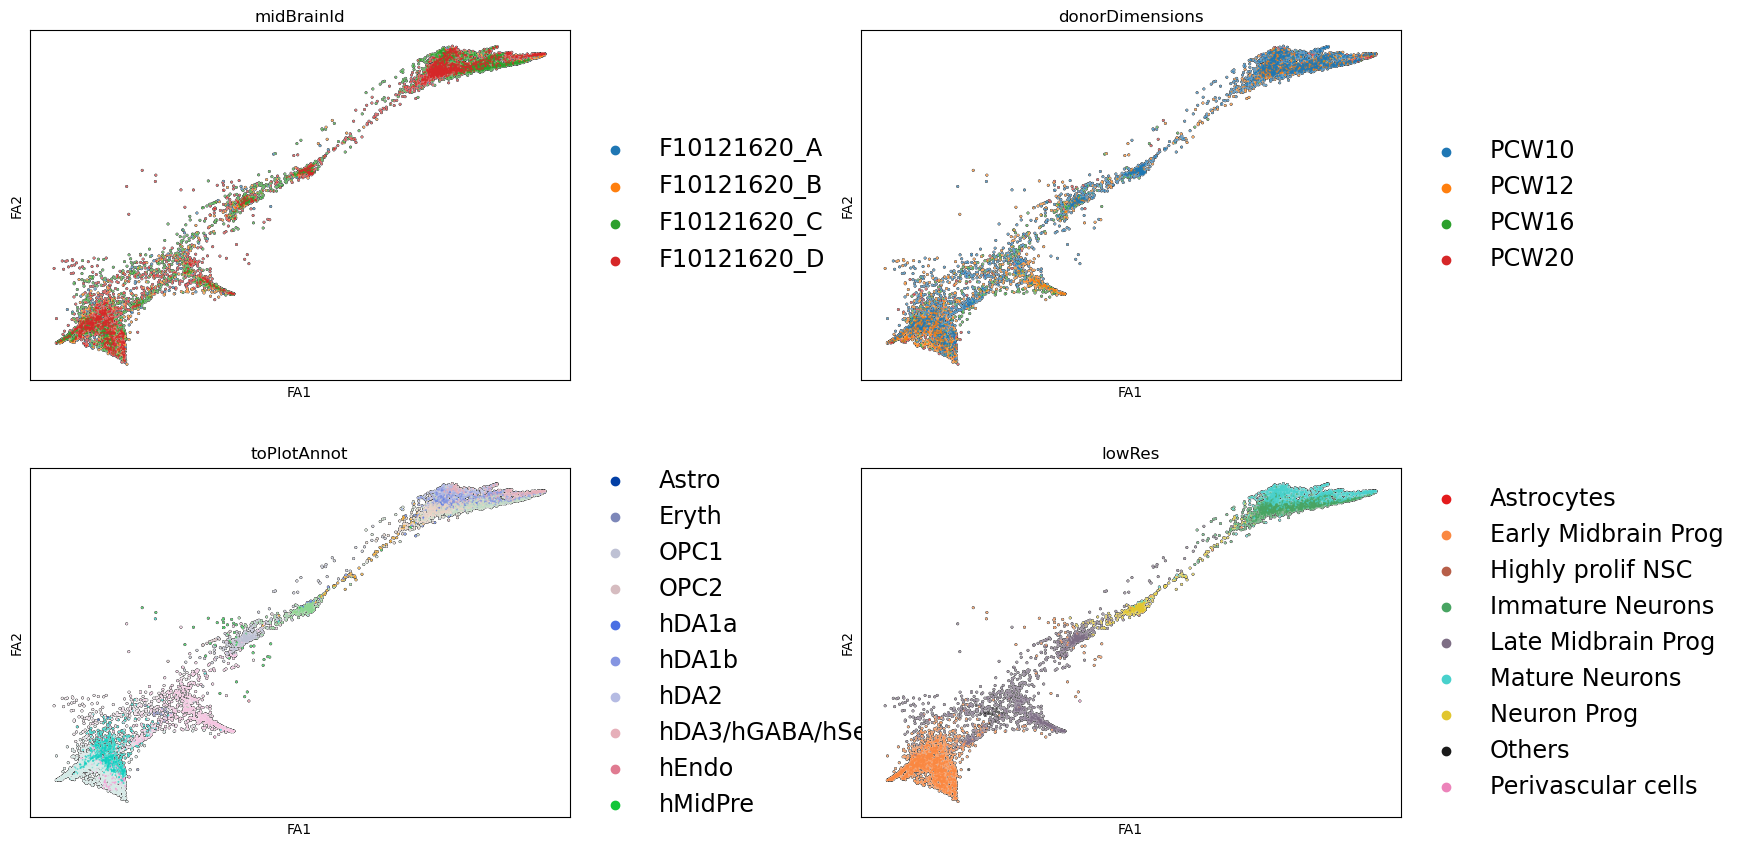

In [7]:
celltype_colors = {
    "Astrocytes": "#e41a1c",
    "Early Midbrain Prog": "#fa8841",
    "Late Midbrain Prog": "#7e6e85",
    "Neuron Prog": "#e1c62f",
    "Highly prolif NSC": "#b75f49",
    "Immature Neurons": "#48a462",
    "Mature Neurons": "#48d1cc",
    "Microglia": "#4a72a6",
    "Perivascular cells": "#ec83ba",
    "Others": "#1a1a1a"
}
Branch_adata.obs["lowRes"] = Branch_adata.obs["lowRes"].astype("category")
Branch_adata.uns["lowRes_colors"] = [celltype_colors[ct] for ct in Branch_adata.obs["lowRes"].cat.categories]

sc.pl.draw_graph(Branch_adata[Branch_adata.obs[endpoint] == 1], color = ["midBrainId","donorDimensions","toPlotAnnot","lowRes"], size = 8, add_outline=True, outline_width=(0.2, 0.05), vmin='p2',vmax='p98', wspace=.4, ncols=2,legend_fontsize='xx-large')


In [8]:
BranchBCs = Branch_adata.obs_names[Branch_adata.obs[endpoint] == 1].tolist()
harmonyTheta = 1
HVGs=pd.read_csv(outdir+"HVG_list_intersection_Curated_"+branchTag+"_PagaTest.txt", sep = "\t")["HVG"] 

In [9]:
#Branch specifi pre-processing

In [10]:
adataBranch = sc.read_h5ad(outdir+"mlo_with_new_annot_rawdata_foetal.h5ad")[BranchBCs]

celltype_colors = {
    "Astrocytes": "#e41a1c",
    "Early Midbrain Prog": "#fa8841",
    "Late Midbrain Prog": "#7e6e85",
    "Neuron Prog": "#e1c62f",
    "Highly prolif NSC": "#b75f49",
    "Immature Neurons": "#48a462",
    "Mature Neurons": "#48d1cc",
    "Microglia": "#4a72a6",
    "Perivascular cells": "#ec83ba",
    "Others": "#1a1a1a"
}

In [11]:
adataBranch.obs["lowRes"] = adataBranch.obs["lowRes"].astype("category")
adataBranch.uns["lowRes_colors"] = [celltype_colors[ct] for ct in adataBranch.obs["lowRes"].cat.categories]

/tmp/paupuigd/28506093/ipykernel_585652/1659210789.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adataBranch.obs["lowRes"] = adataBranch.obs["upperRes"]


In [12]:
goodcls = adataBranch.obs.groupby(["lowRes"]).size()[adataBranch.obs.groupby(["lowRes"]).size() >= 50].index.tolist()
adataBranch = adataBranch[adataBranch.obs["lowRes"].isin(goodcls)]

/tmp/paupuigd/28506093/ipykernel_585652/752398545.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  goodcls = adataBranch.obs.groupby(["lowRes"]).size()[adataBranch.obs.groupby(["lowRes"]).size() >= 50].index.tolist()
/tmp/paupuigd/28506093/ipykernel_585652/752398545.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  goodcls = adataBranch.obs.groupby(["lowRes"]).size()[adataBranch.obs.groupby(["lowRes"]).size() >= 50].index.tolist()


In [13]:
adataBranch.layers["unscaled"] = adataBranch.X.copy()


/tmp/paupuigd/28506093/ipykernel_585652/3479580358.py:1: ImplicitModificationWarning: Setting element `.layers['unscaled']` of view, initializing view as actual.
  adataBranch.layers["unscaled"] = adataBranch.X.copy()


In [14]:
adataBranch.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'origin', 'vcfId',
       'midBrainId', 'midBrainIndex', 'donorId', 'donorDimensions',
       'timePoint', 'percent.mt', 'percent.ribo', 'S.Score', 'G2M.Score',
       'Phase', 'seurat_clusters', 'originDimensions', 'dimensionsTime',
       'seurat_clusters_24_Annot', 'toPlotAnnot', 'upperRes',
       'dimensionsTime2', 'old.ident', 'lowRes'],
      dtype='object')

In [15]:
sc.pp.normalize_total(adataBranch, target_sum=1e4)

sc.pp.log1p(adataBranch)
adataBranch.raw = adataBranch

adataBranch = adataBranch[:,HVGs]
adataBranch.var["highly_variable"] = True


/tmp/paupuigd/28506093/ipykernel_585652/420258948.py:7: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adataBranch.var["highly_variable"] = True


In [16]:
adataBranch.obs["toPlotAnnot"].value_counts()

toPlotAnnot
hRgl1               1170
hNbDA                808
hRgl3caudal          727
hProgFPM             723
hDA1b                714
hNbGaba              576
OPC1                 367
hNPro                322
hDA2                 303
hDA3/hGABA/hSer      291
hRgl2/immAstro       243
hDA1a                106
hRgl4/MultiEpend     105
hPreDA                68
hMidPre               51
OPC2                  15
Name: count, dtype: int64

In [17]:
sc.pp.regress_out(adataBranch, ['nCount_RNA','percent.mt'], n_jobs=4)
sc.pp.scale(adataBranch, zero_center=False)

In [18]:
sc.tl.pca(adataBranch, svd_solver='arpack', use_highly_variable=True)
sce.pp.harmony_integrate(adataBranch, 'midBrainId', max_iter_harmony=20,adjusted_basis="X_pca",random_state = 0, theta = harmonyTheta, lamb = 2)


/PUHTI_TYKKY_gU5QJ1k/miniforge/envs/env1/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:374: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
2025-06-12 14:59:45,100 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-06-12 14:59:46,210 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-06-12 14:59:46,228 - harmonypy - INFO - Iteration 1 of 20
2025-06-12 14:59:47,191 - harmonypy - INFO - Iteration 2 of 20
2025-06-12 14:59:48,175 - harmonypy - INFO - Iteration 3 of 20
2025-06-12 14:59:49,154 - harmonypy - INFO - Iteration 4 of 20
2025-06-12 14:59:50,157 - harmonypy - INFO - Iteration 5 of 20
2025-06-12 14:59:50,708 - harmonypy - INFO - Iteration 6 of 20
2025-06-12 14:59:51,159 - harmonypy - INFO - Iteration 7 of 20
2025-06-12 14:5

In [19]:
adataBranch

AnnData object with n_obs × n_vars = 6589 × 1709
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'origin', 'vcfId', 'midBrainId', 'midBrainIndex', 'donorId', 'donorDimensions', 'timePoint', 'percent.mt', 'percent.ribo', 'S.Score', 'G2M.Score', 'Phase', 'seurat_clusters', 'originDimensions', 'dimensionsTime', 'seurat_clusters_24_Annot', 'toPlotAnnot', 'upperRes', 'dimensionsTime2', 'old.ident', 'lowRes'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'highly_variable', 'mean', 'std'
    uns: 'lowRes_colors', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'unscaled'

In [20]:
sc.pp.neighbors(adataBranch,use_rep="X_pca",n_neighbors=50, n_pcs=10, random_state=0)

sc.tl.umap(adataBranch, random_state=0)

/PUHTI_TYKKY_gU5QJ1k/miniforge/envs/env1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


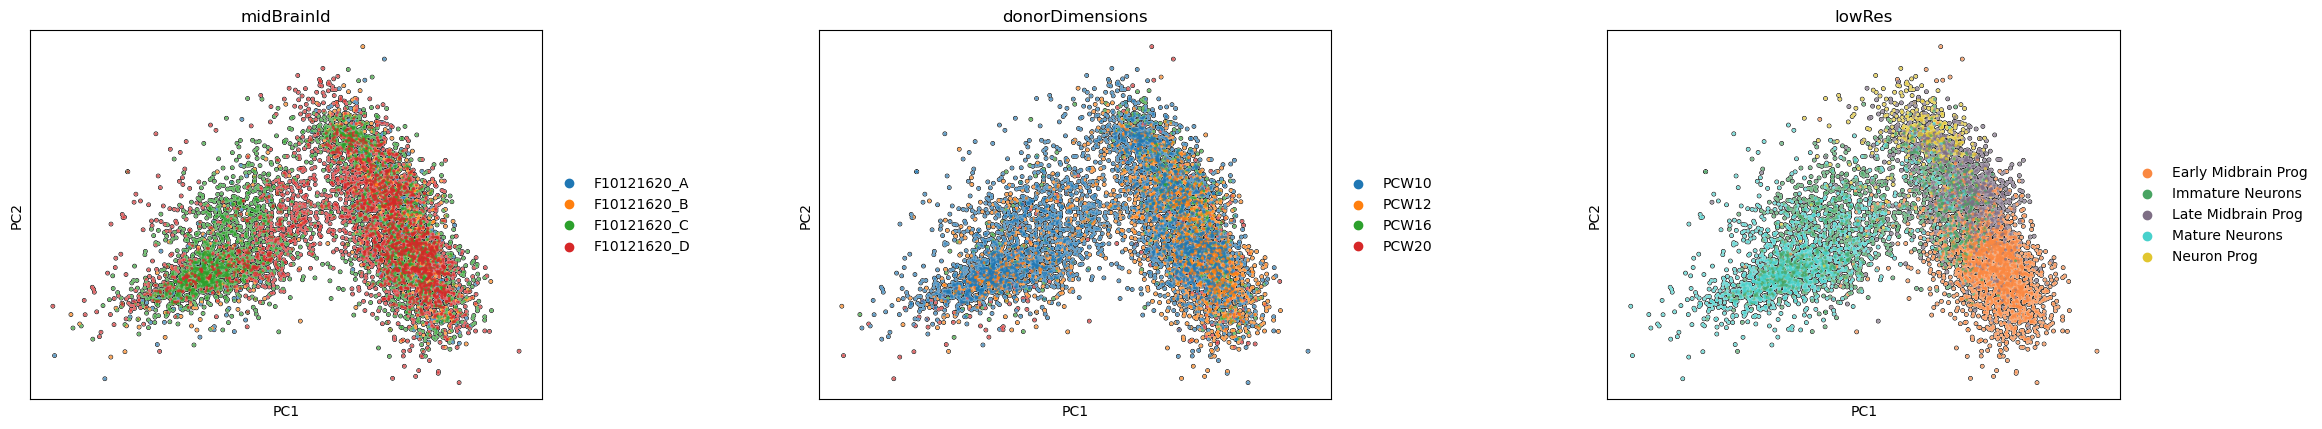

In [21]:
sc.pl.pca(adataBranch, color = ["midBrainId","donorDimensions",'lowRes'], size = 20,add_outline=True, outline_width=(0.2, 0.05), vmin='p2',vmax='p98',wspace=.4)

In [22]:
vector=False
n=20
pdDict = {}

if vector:
    sc.settings._vector_friendly = False
for pc in  [0,1]:
    TopPC_IDX = np.argpartition(adataBranch.varm["PCs"][:,pc], -n)[-n:]
    DownPC_IDX = np.argpartition(adataBranch.varm["PCs"][:,pc], n)[:n]
    pdDict[pc] = pd.DataFrame(adataBranch.varm["PCs"][:,pc][TopPC_IDX], index = adataBranch.var_names[TopPC_IDX], columns=["pc"+str(pc+1)])
    pdDict[pc] = pd.concat([pdDict[pc],pd.DataFrame(adataBranch.varm["PCs"][:,pc][DownPC_IDX], index = adataBranch.var_names[DownPC_IDX], columns=["pc"+str(pc+1)])])
    pdDict[pc]["gene"] = pdDict[pc].index.tolist()
    if pc == 0:
        pdDict[pc] = pdDict[pc].sort_values("pc"+str(pc+1))
    elif pc == 1:
        pdDict[pc] = pdDict[pc].sort_values("pc"+str(pc+1), ascending = False)
    
    

/tmp/paupuigd/28506093/ipykernel_585652/3255108831.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdDict[0], x="gene", y="pc1" ,palette=colors,ax=ax[1][0], zorder=3 ).tick_params(axis='x', rotation=90, labelsize=8)
/tmp/paupuigd/28506093/ipykernel_585652/3255108831.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdDict[1], x="pc2", y="gene",palette=colors,ax=ax[0][1], zorder=3 ).tick_params(axis='y',


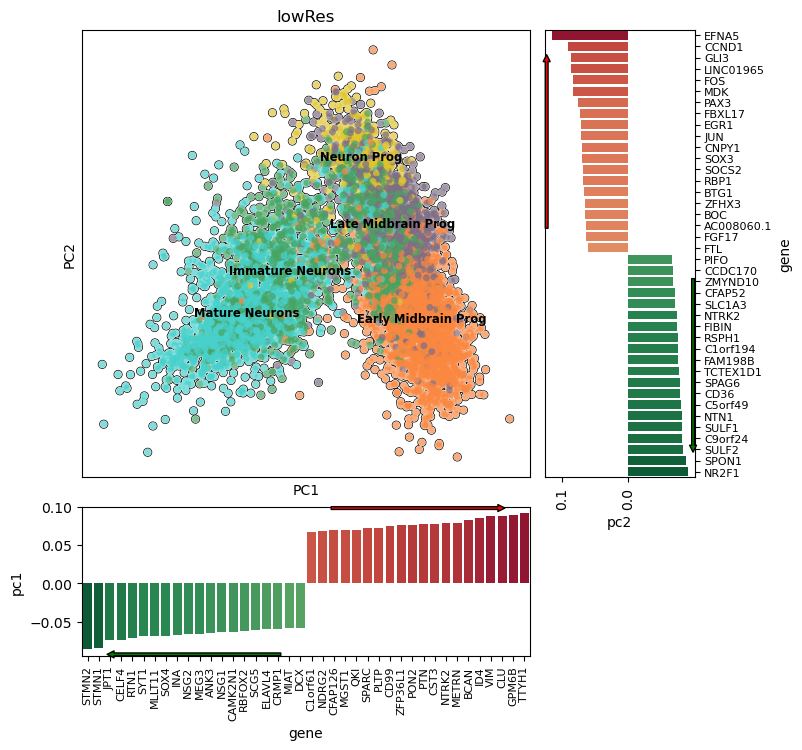

In [23]:
figsize = (6, 6)  #(width, height)
#Set axes
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=figsize,gridspec_kw={'width_ratios': [3, 1],'height_ratios': [3, 1]})

fig.tight_layout(pad=-2, h_pad=0)   #space between plots

ax1plot = sc.pl.pca(adataBranch, components=['1,2'], color=["lowRes"], 
                    ncols=1, add_outline=True, legend_loc="on data",size=100,legend_fontsize="small",
                    outline_width=(.1,.05), wspace=.2, show=False, ax=ax[0][0])



norm = TwoSlopeNorm(vmin=pdDict[0]["pc1"].min(), vcenter=0, vmax=pdDict[0]["pc1"].max())
colors = [plt.cm.RdYlGn_r(norm(c)) for c in pdDict[0]["pc1"]]
sns.barplot(data=pdDict[0], x="gene", y="pc1" ,palette=colors,ax=ax[1][0], zorder=3 ).tick_params(axis='x', rotation=90, labelsize=8)
ax[1][0].annotate("", xy=(.95,.99),xytext=(0.55, 0.99),
                  xycoords='axes fraction',
                  arrowprops=dict(arrowstyle="simple",facecolor="red"))
ax[1][0].annotate("", xy=(.05,.01),xytext=(0.45, 0.01),
                  xycoords='axes fraction',
                  arrowprops=dict(arrowstyle="simple",facecolor="green"))


norm = TwoSlopeNorm(vmin=pdDict[1]["pc2"].min(), vcenter=0, vmax=pdDict[1]["pc2"].max())
colors = [plt.cm.RdYlGn_r(norm(c)) for c in pdDict[1]["pc2"]]
sns.barplot(data=pdDict[1], x="pc2", y="gene",palette=colors,ax=ax[0][1], zorder=3 ).tick_params(axis='y',  
                                                                                                              labelsize=8, 
                                                                                                              labelright=True, labelleft=False,
                                                                                                              right=True, left=False)
ax[0][1].tick_params(axis='x', rotation=90)

ax[0][1].annotate("", xy=(.01,.95),xytext=(0.01, 0.55),
                  xycoords='axes fraction',
                  arrowprops=dict(arrowstyle="simple",facecolor="red"))
ax[0][1].annotate("", xy=(.99,.05),xytext=(0.99, 0.45),
                  xycoords='axes fraction',
                  arrowprops=dict(arrowstyle="simple",facecolor="green"))



ax[0][1].invert_xaxis()
ax[0][1].yaxis.set_label_position("right")
fig.delaxes(ax[1][1])

sc.settings._vector_friendly = True
fig.savefig(os.path.join(figDir, "suppFigure9FI.svg"), dpi=300, bbox_inches='tight')


In [24]:
pdDict = {}
for pc in  [0]:
    pdDict[pc] = pd.DataFrame(adataBranch.varm["PCs"][:,pc], index = adataBranch.var_names.tolist(), columns=["loading"])
    pdDict[pc]["gene"] = pdDict[pc].index.tolist()
    pdDict[pc] = pdDict[pc].sort_values("loading")
    pdDict[pc]["component"] = "pc"+str(pc+1)
    
TopLoadings = pdDict[pc]
TopLoadings

,loading,gene,component
STMN2,-0.085651,STMN2,pc1
STMN1,-0.084055,STMN1,pc1
JPT1,-0.074201,JPT1,pc1
CELF4,-0.074177,CELF4,pc1
RTN1,-0.071484,RTN1,pc1
...,...,...,...
ID4,0.084656,ID4,pc1
VIM,0.087978,VIM,pc1
CLU,0.088190,CLU,pc1
GPM6B,0.089454,GPM6B,pc1


In [25]:
adataBranch.obs["lowRes_noSpace"] = adataBranch.obs['lowRes'].str.replace(' ', '_')
adataBranch.obs["lowRes_noSpace"] = adataBranch.obs["lowRes_noSpace"].astype('category')


In [26]:
#Match the original categories (with spaces) to their colors
original_categories = adataBranch.obs["lowRes"].cat.categories
original_colors = adataBranch.uns["lowRes_colors"]

#Create a mapping from normalized names (with underscores) to colors
normalized_names = [cat.replace(' ', '_') for cat in original_categories]
color_map = dict(zip(normalized_names, original_colors))

#Assign colors to the new category based on normalized names
adataBranch.uns["lowRes_noSpace_colors"] = np.array(
    [color_map[cat] for cat in adataBranch.obs["lowRes_noSpace"].cat.categories]
)

color_map

{'Early_Midbrain_Prog': np.str_('#fa8841'),
 'Immature_Neurons': np.str_('#48a462'),
 'Late_Midbrain_Prog': np.str_('#7e6e85'),
 'Mature_Neurons': np.str_('#48d1cc'),
 'Neuron_Prog': np.str_('#e1c62f')}

In [27]:
ColorDict = {}
for i in ['lowRes_noSpace','donorDimensions']:
    ColorDict[i] = dict(zip(adataBranch.obs[i].cat.categories,adataBranch.uns["{}_colors".format(i)]))
PlotOrder = {"lowRes_noSpace":['Early_Midbrain_Prog','Late_Midbrain_Prog','Neuron_Prog', 'Immature_Neurons', 'Mature_Neurons'],
             "donorDimensions":["PCW10","PCW12","PCW16","PCW20"]}

/tmp/paupuigd/28506093/ipykernel_585652/2368945324.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=PCRegr, x="variable", y="value", ax = axes[n],whis=[0, 100],palette=ColorDict[c], order=PlotOrder[c],hue_order=PlotOrder[c])
/tmp/paupuigd/28506093/ipykernel_585652/2368945324.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=PCRegr, x="variable", y="value", ax = axes[n],whis=[0, 100],palette=ColorDict[c], order=PlotOrder[c],hue_order=PlotOrder[c])
/tmp/paupuigd/28506093/ipykernel_585652/2368945324.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the sam

<Figure size 640x480 with 0 Axes>

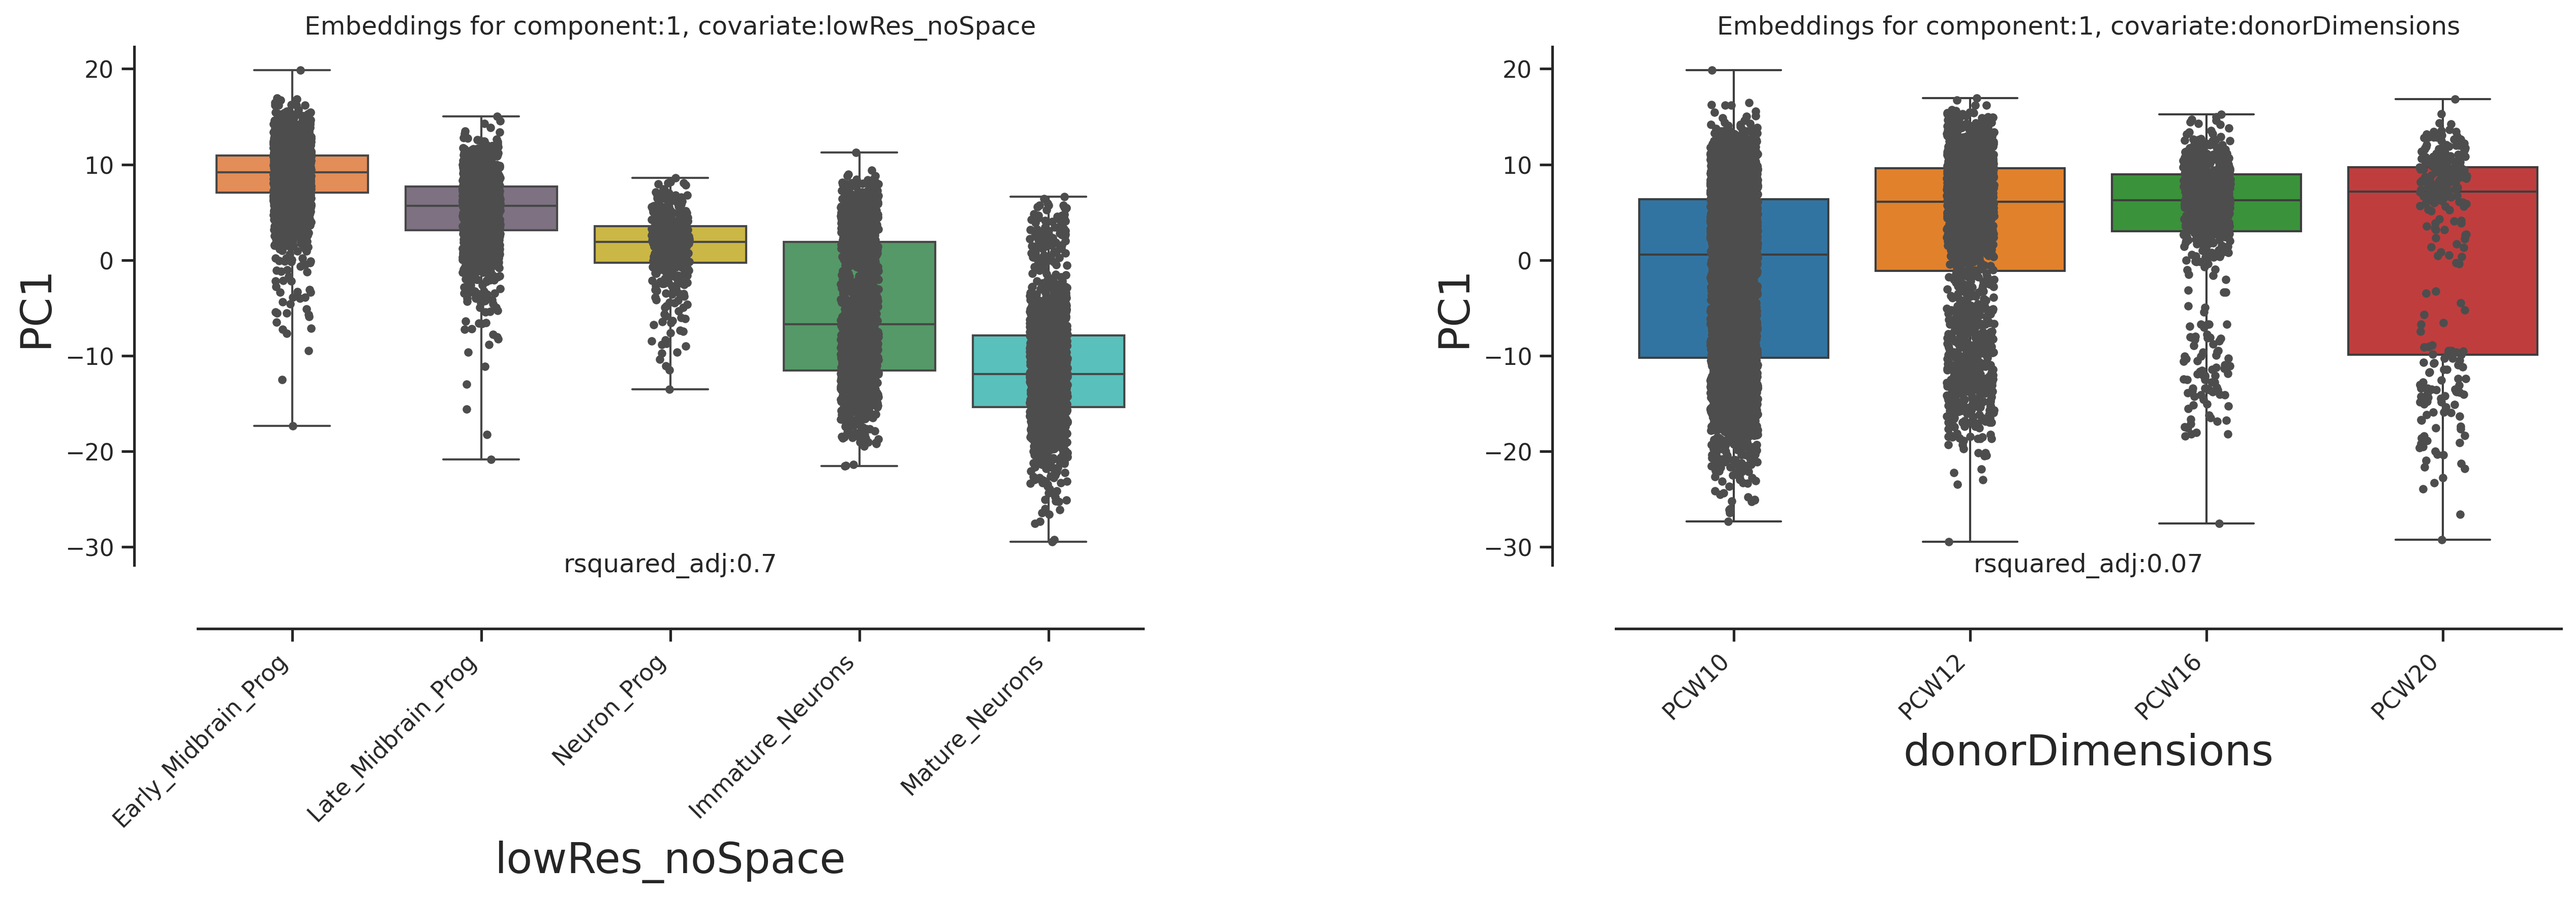

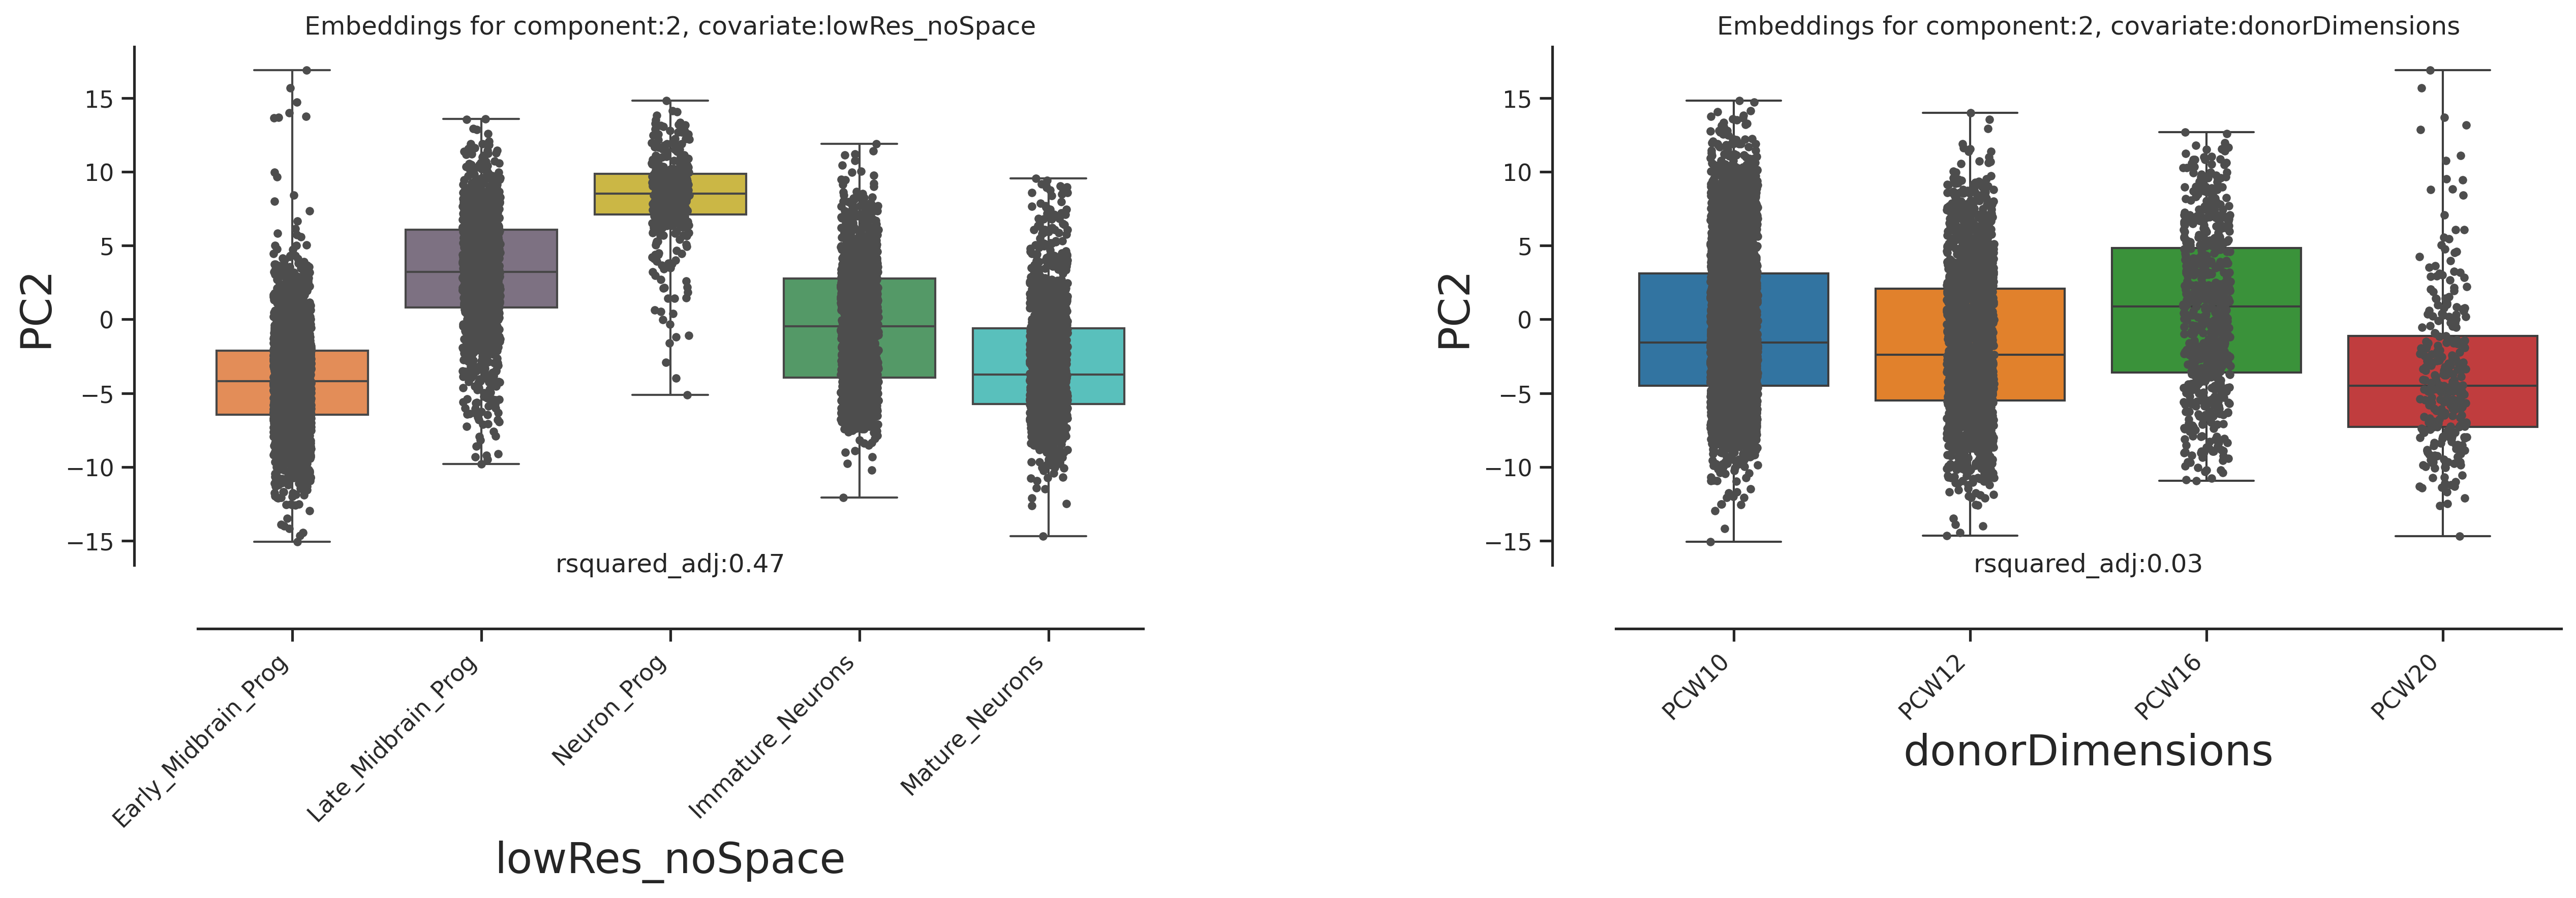

In [28]:
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
PCRegrDict = {}
npcs = 2
covToTest = ["lowRes_noSpace","donorDimensions"]
sns.set_theme(style="ticks")
varianceSummary = pd.DataFrame()
for i in range(npcs):
	adataBranch.obsm["X_pca"]
	for n,c in enumerate(covToTest):
		Dummies = pd.get_dummies(adataBranch.obs[c])
		PCRegr = (Dummies.T * adataBranch.obsm["X_pca"][:,i].T).T.melt()
		PCRegr = PCRegr[PCRegr["value"] != 0]
		PCRegr["variable"] = PCRegr["variable"].astype("category")
		PCRegr["cov"] = c
		PCRegrDict["PC:{}_COV:{}".format(i+1,c)] = PCRegr.copy()
		sns.despine(offset=30)
		PCRegrModel = pd.get_dummies(PCRegrDict["PC:{}_COV:{}".format(i+1,c)], "variable").copy()
		formula = "".join(["value ~ "," + ".join(["C("+c+")" for c in PCRegrModel.columns[1:-1].tolist()])])
		fit = ols(formula, data=PCRegrModel).fit() 
		fit.rsquared_adj
		PCRegr["rsquared_adj"] = fit.rsquared_adj
		PCRegr["PC"] = i
		varianceSummary = pd.concat([varianceSummary,PCRegr ], ignore_index=True)

CovOrder = {i:varianceSummary.drop_duplicates(["PC","cov"])[varianceSummary.drop_duplicates(["PC","cov"])["PC"] == i].sort_values("rsquared_adj", ascending=False)["cov"].tolist() for i in varianceSummary["PC"].unique().tolist()}
for i in range(npcs):
	fig, axes = plt.subplots(1,len(covToTest), figsize=(20,5), dpi=300, sharex=False,sharey=False)
	plt.subplots_adjust(wspace=.5)
	adataBranch.obsm["X_pca"]
	for n,c in enumerate(CovOrder[i]):
		PCRegr = varianceSummary[(varianceSummary["PC"] == i) & (varianceSummary["cov"] == c)]
		sns.boxplot(data=PCRegr, x="variable", y="value", ax = axes[n],whis=[0, 100],palette=ColorDict[c], order=PlotOrder[c],hue_order=PlotOrder[c])
		sns.stripplot(data=PCRegr, x="variable", y="value", size=4, color=".3",ax = axes[n], order=PlotOrder[c],hue_order=PlotOrder[c])
		axes[n].title.set_text('Embeddings for component:{}, covariate:{}'.format(i+1,c))
		axes[n].set_xlabel(c, fontsize=20)
		axes[n].set_ylabel("PC{}".format(i+1), fontsize=20)
		sns.despine(offset=30)
		fit.rsquared_adj = PCRegr["rsquared_adj"].values[0]
		axes[n].text(0.5, 0, "rsquared_adj:{}".format(round(fit.rsquared_adj,2)), horizontalalignment='center', verticalalignment='center',transform=axes[n].transAxes)
		axes[n].tick_params(axis="x", rotation=45)
		plt.xticks(rotation=45)
		fig.autofmt_xdate(rotation=45); fig.savefig(os.path.join(figDir, "suppFigure9GH.svg"), dpi=300, bbox_inches='tight')


In [29]:
TopLoadings["rank"] = TopLoadings["loading"].rank()
TopLoadings["Zero"] = 0

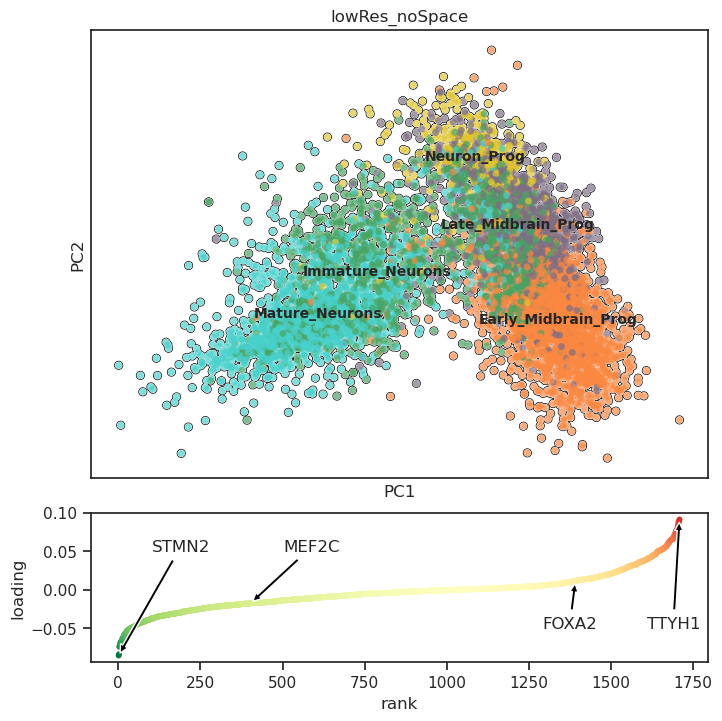

In [30]:
#if you want vector sc.settings._vector_friendly = False
sns.set_style("ticks")
vector=True
n=20
pdDict = {}
pylab.rcParams['figure.figsize'] = (10, 10)

if vector:
    sc.settings._vector_friendly = False
for pc in  [0,1]:
    TopPC_IDX = np.argpartition(adataBranch.varm["PCs"][:,pc], -n)[-n:]
    DownPC_IDX = np.argpartition(adataBranch.varm["PCs"][:,pc], n)[:n]
    pdDict[pc] = pd.DataFrame(adataBranch.varm["PCs"][:,pc][TopPC_IDX], index = adataBranch.var_names[TopPC_IDX], columns=["pc"+str(pc+1)])
    pdDict[pc] = pd.concat([pdDict[pc],pd.DataFrame(adataBranch.varm["PCs"][:,pc][DownPC_IDX], index = adataBranch.var_names[DownPC_IDX], columns=["pc"+str(pc+1)])])
    pdDict[pc]["gene"] = pdDict[pc].index.tolist()
    if pc == 0:
        pdDict[pc] = pdDict[pc].sort_values("pc"+str(pc+1))
    elif pc == 1:
        pdDict[pc] = pdDict[pc].sort_values("pc"+str(pc+1), ascending = False)
    
    

figsize = (6, 6)  #(width, height)
#Set axes
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=figsize,gridspec_kw={'height_ratios': [3, 1]})

fig.tight_layout(pad=-2, h_pad=0)   #space between plots

ax1plot = sc.pl.pca(adataBranch, components=['1,2'], color=["lowRes_noSpace"], 
                    ncols=1, add_outline=True, legend_loc="on data",size=100,legend_fontsize="small",
                    outline_width=(.1,.05), wspace=.2, show=False, ax=ax[0])


colors = [plt.cm.RdYlGn_r(norm(c)) for c in TopLoadings["loading"]]
sns.scatterplot(data=TopLoadings, x="rank", y="loading", linewidth=0, hue = "rank",palette=colors, size=.1, ax=ax[1], alpha=1)

#
#
for i in ["STMN2","MEF2C","FOXA2","TTYH1"]:
    offsety =  -.05 if TopLoadings.loc[i,"loading"] > 0 else .05
    offsetx =  -100 if TopLoadings.loc[i,"loading"] > 0 else 100
    ax[1].annotate(i, 
                xy=(TopLoadings.loc[i,"rank"],TopLoadings.loc[i,"loading"]),
                xytext=(TopLoadings.loc[i,"rank"] + offsetx, offsety),
    xycoords='data',
    arrowprops=dict(arrowstyle="simple",facecolor="black",))

ax[1].get_legend().remove()




sc.settings._vector_friendly = True
pylab.rcParams['figure.figsize'] = (4, 4)
fig.savefig(os.path.join(figDir, f"PCA_loadingsDistr.{branchTag}.svg"), dpi=300, bbox_inches='tight')

23
13
['SHH', 'WNT5A', 'FOXA2', 'OTX2', 'NR4A2', 'EN1', 'EN2', 'LHX1', 'KCNJ6', 'ALDH1A1', 'TH', 'DDC', 'SLC18A2']


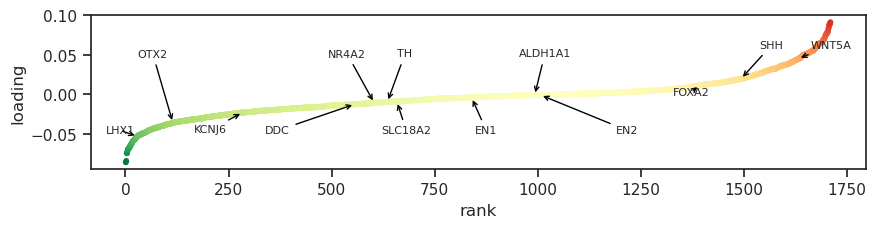

In [31]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import seaborn as sns

figsize = (10, 2)
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=figsize)

# Plot the points with scatter
colors = [plt.cm.RdYlGn_r(norm(c)) for c in TopLoadings["loading"]]
sns.scatterplot(data=TopLoadings, x="rank", y="loading", linewidth=0, hue="rank", palette=colors, size=.1, ax=ax, alpha=1)

# Genes of interest
genes_of_interest = ["SHH", "WNT1", "WNT5A", "FGF8", "BMP5", "BMP7", "LMX1A", "LMX1B", "FOXA2", "OTX2", "NR4A2", "PITX3", "EN1",
                     "EN2", "SOX6", "LHX1", "KCNJ6", "LBD1", "ALDH1A1", "TH", "DDC", "SLC18A2", "AADC"]

# Subset genes that are in the data
genes_of_interest_tl = [g for g in genes_of_interest if g in TopLoadings.index]

print(len(genes_of_interest))
print(len(genes_of_interest_tl))
print(genes_of_interest_tl)

# Create the list for adjusted text objects
texts = []
for gene in genes_of_interest_tl:
    # Adjust the offsets to push the text further away from the point
    offset_y = 0.07 if TopLoadings.loc[gene, "loading"] > 0 else -0.1
    offset_x = 75 if TopLoadings.loc[gene, "loading"] > 0 else -150  # Make this larger for more separation
     
    
    texts.append(
        ax.annotate(gene,
                    xy=(TopLoadings.loc[gene, "rank"], TopLoadings.loc[gene, "loading"]),
                    xytext=(TopLoadings.loc[gene, "rank"] + offset_x, TopLoadings.loc[gene, "loading"] + offset_y),
                    textcoords='data',
                    fontsize=8,
                    arrowprops=dict(arrowstyle="->", color='black', lw=1)
                   )
    )

# Adjust the text labels to avoid overlaps and get better positioning
adjust_text(texts, ax=ax, 
            expand_points=(2, 2), expand_text=(1.2, 1.2), force_text=(0.5, 0.5))

# Remove the legend
ax.get_legend().remove()

# Save the figure
sc.settings._vector_friendly = True
pylab.rcParams['figure.figsize'] = (16, 2)
fig.savefig(os.path.join(figDir, "mainFigure3J.svg"), dpi=300, bbox_inches='tight')


In [32]:
TopLoadings

,loading,gene,component,rank,Zero
STMN2,-0.085651,STMN2,pc1,1.0,0
STMN1,-0.084055,STMN1,pc1,2.0,0
JPT1,-0.074201,JPT1,pc1,3.0,0
CELF4,-0.074177,CELF4,pc1,4.0,0
RTN1,-0.071484,RTN1,pc1,5.0,0
...,...,...,...,...,...
ID4,0.084656,ID4,pc1,1705.0,0
VIM,0.087978,VIM,pc1,1706.0,0
CLU,0.088190,CLU,pc1,1707.0,0
GPM6B,0.089454,GPM6B,pc1,1708.0,0


In [33]:
#DPT

In [34]:
adataBranch

AnnData object with n_obs × n_vars = 6589 × 1709
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'origin', 'vcfId', 'midBrainId', 'midBrainIndex', 'donorId', 'donorDimensions', 'timePoint', 'percent.mt', 'percent.ribo', 'S.Score', 'G2M.Score', 'Phase', 'seurat_clusters', 'originDimensions', 'dimensionsTime', 'seurat_clusters_24_Annot', 'toPlotAnnot', 'upperRes', 'dimensionsTime2', 'old.ident', 'lowRes', 'lowRes_noSpace'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'highly_variable', 'mean', 'std'
    uns: 'lowRes_colors', 'log1p', 'pca', 'neighbors', 'umap', 'midBrainId_colors', 'donorDimensions_colors', 'lowRes_noSpace_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'unscaled'
    obsp: 'distances', 'connectivities'

In [35]:
common_barcodes = adataBranch.obs_names.intersection(Branch_adata.obs_names)
adataBranch.obs.loc[common_barcodes, "leiden_1"] = Branch_adata.obs.loc[common_barcodes, "leiden_1"]
adataBranch

AnnData object with n_obs × n_vars = 6589 × 1709
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'origin', 'vcfId', 'midBrainId', 'midBrainIndex', 'donorId', 'donorDimensions', 'timePoint', 'percent.mt', 'percent.ribo', 'S.Score', 'G2M.Score', 'Phase', 'seurat_clusters', 'originDimensions', 'dimensionsTime', 'seurat_clusters_24_Annot', 'toPlotAnnot', 'upperRes', 'dimensionsTime2', 'old.ident', 'lowRes', 'lowRes_noSpace', 'leiden_1'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'highly_variable', 'mean', 'std'
    uns: 'lowRes_colors', 'log1p', 'pca', 'neighbors', 'umap', 'midBrainId_colors', 'donorDimensions_colors', 'lowRes_noSpace_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'unscaled'
    obsp: 'distances', 'connectivities'

In [36]:
cluster3_mask = adataBranch.obs["leiden_1"] == "3"
cluster3_data = adataBranch[cluster3_mask, :]

top2a_idx = cluster3_data[:, ["TUBB4B"]].X.argmax()
RootName = cluster3_data.obs_names[top2a_idx]

root_idx = np.where(adataBranch.obs_names == RootName)[0][0]
adataBranch.uns["iroot"] = root_idx

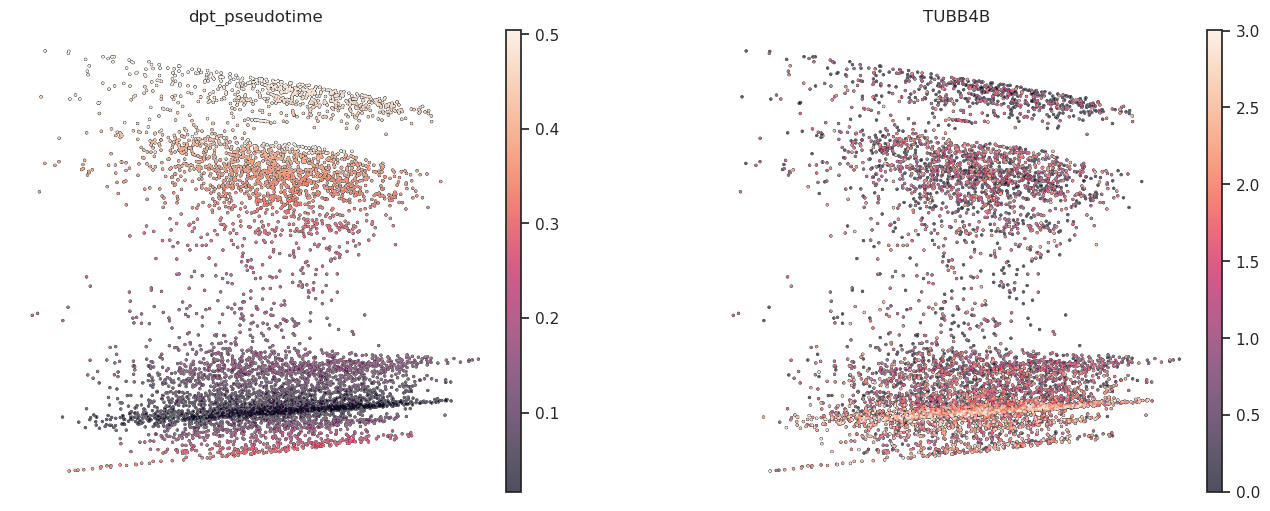

In [37]:
figsize = (6, 6)
pylab.rcParams['figure.figsize'] = (6, 6)
sc.tl.dpt(adataBranch)
sc.pl.diffmap(adataBranch, color = ["dpt_pseudotime","TUBB4B"],size=10,add_outline=True, outline_width=(0.2, 0.05), vmin='p2',vmax='p98', legend_fontsize="xx-large", frameon=False, wspace=.3, legend_loc="on data")

In [38]:
adataBranch.write_h5ad(outdir+"adataLineage."+branchTag+".h5ad")

In [39]:
adataBranch

AnnData object with n_obs × n_vars = 6589 × 1709
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'origin', 'vcfId', 'midBrainId', 'midBrainIndex', 'donorId', 'donorDimensions', 'timePoint', 'percent.mt', 'percent.ribo', 'S.Score', 'G2M.Score', 'Phase', 'seurat_clusters', 'originDimensions', 'dimensionsTime', 'seurat_clusters_24_Annot', 'toPlotAnnot', 'upperRes', 'dimensionsTime2', 'old.ident', 'lowRes', 'lowRes_noSpace', 'leiden_1', 'dpt_pseudotime'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'highly_variable', 'mean', 'std'
    uns: 'lowRes_colors', 'log1p', 'pca', 'neighbors', 'umap', 'midBrainId_colors', 'donorDimensions_colors', 'lowRes_noSpace_colors', 'iroot', 'diffmap_evals'
    obsm: 'X_pca', 'X_umap', 'X_diffmap'
    varm: 'PCs'
    layers: 'unscaled'
    obsp: 'distances', 'connectivities'

In [40]:
timeCov="dpt_pseudotime"
from matplotlib.pyplot import figure
sc.settings.set_figure_params(dpi=100)
pylab.rcParams['figure.figsize'] = (10, 8)

In [41]:
sns.set_style("white")

In [42]:
cov = "donorDimensions"

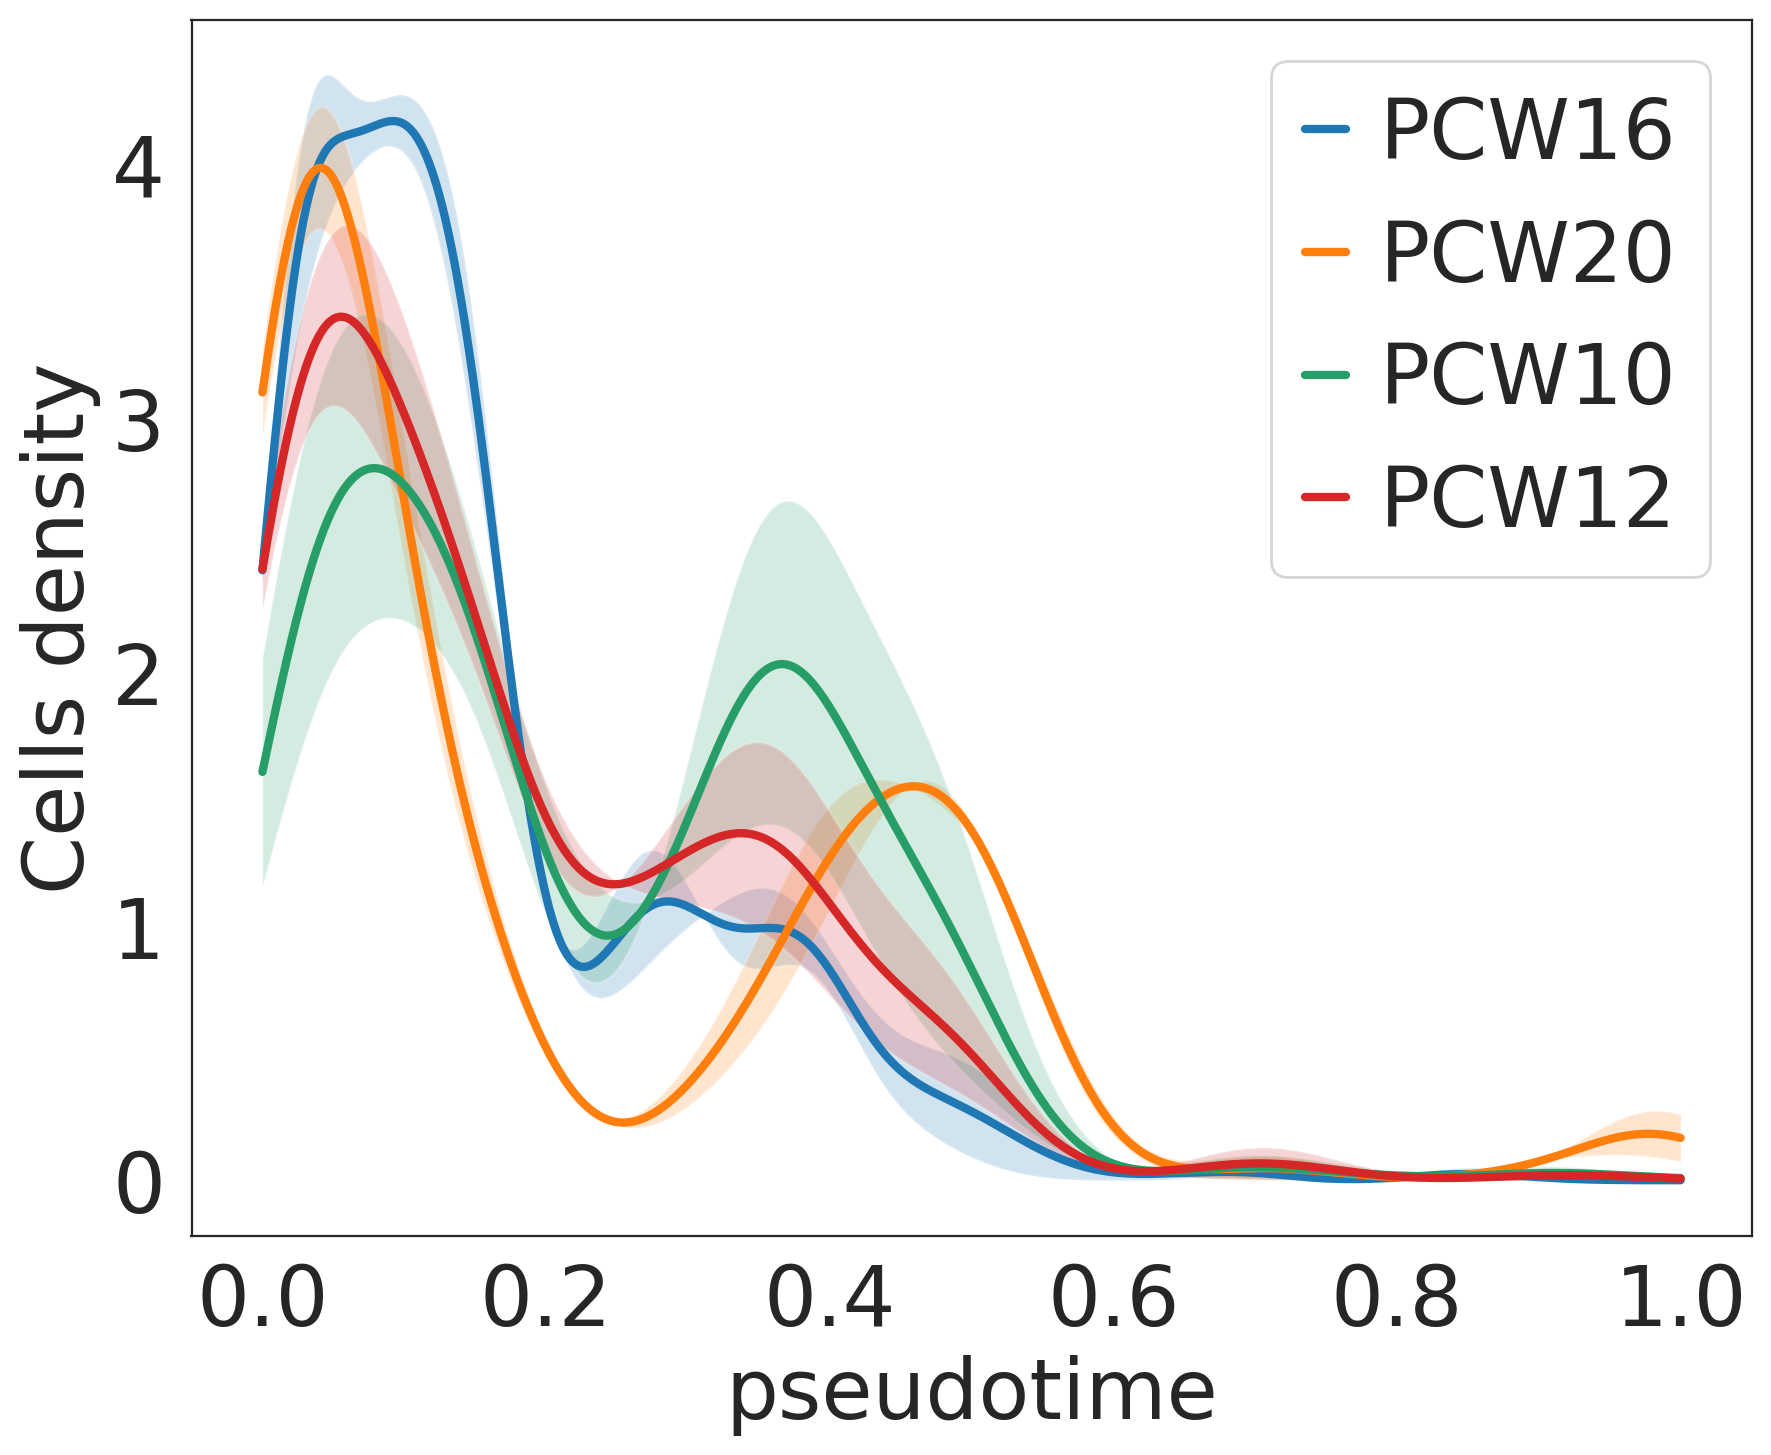

In [43]:
for Stage in adataBranch.obs["donorDimensions"].unique(): 
    StageLT = adataBranch.obs[adataBranch.obs["donorDimensions"] == Stage]
    
    StageLT_smoothed = pd.DataFrame(index=np.linspace(0, 1, 10000))
    for dataset in StageLT["midBrainId"].unique():
        datasetLT = StageLT.loc[StageLT["midBrainId"] == dataset,timeCov]
        _bandwidth = round((datasetLT.max() - datasetLT.min()) * binWidthRate, 2)
    
        KernelData = datasetLT

        
        X = KernelData.values[:, np.newaxis]
        X_plot = np.linspace(0, 1, 10000)[:, np.newaxis]

        # Pick bandwidht
        kde_Calc = KernelDensity(kernel="gaussian", bandwidth=_bandwidth).fit(X)
        Y=np.exp(kde_Calc.score_samples(X_plot))
        
        StageLT_smoothed[dataset] = Y
        
    StageLT_smoothed["dpt_cut"] = StageLT_smoothed.index.tolist()
        
    # Calculate error and mean on smoothe values ()

    StageLT_smoothed["mean"] = StageLT_smoothed[[i for i in StageLT_smoothed.columns if i not in ['dpt_cut','stdev']]].mean(axis =1)
    StageLT_smoothed["stdev"] = StageLT_smoothed[[i for i in StageLT_smoothed.columns if i not in ['dpt_cut','stdev']]].std(axis =1)
    StageLT_smoothed["errMin"] = StageLT_smoothed["mean"] - StageLT_smoothed["stdev"]
    StageLT_smoothed["errMax"] = StageLT_smoothed["mean"] + StageLT_smoothed["stdev"]
    StageLT_smoothed["errMin"] = np.where(StageLT_smoothed["errMin"] < 0, 0, StageLT_smoothed["errMin"])
    
    plt.plot(StageLT_smoothed["dpt_cut"], StageLT_smoothed["mean"], '-', label =Stage,linewidth = 3)
    plt.fill_between(StageLT_smoothed["dpt_cut"], StageLT_smoothed["errMin"], StageLT_smoothed["errMax"] , alpha=0.2)
    plt.xlabel('pseudotime', size=30)
    plt.xticks(size=30)
    plt.yticks(size=30)

    plt.ylabel('Cells density', size=30)
    plt.legend(prop={'size': 30})
    plt.savefig(figDir+"LineageFigures.dpt."+branchTag+".svg")

 

In [44]:
##Tradeseq within lineage

In [45]:
obs = adataBranch.obs
obsm = adataBranch.obsm

In [46]:
adataTradeseq = sc.read_h5ad(outdir+'mlo_with_new_annot_rawdata_foetal.h5ad')[obs.index]
#Sample extra genes to ensure fair unbyased normalization
ExtraNormGenes = random.sample(adataTradeseq.var_names[~adataTradeseq.var_names.isin(HVGs)].tolist(), len(HVGs.tolist()))
adataTradeseq = adataTradeseq[:,HVGs.tolist()+ExtraNormGenes]

In [47]:
adataBranch

AnnData object with n_obs × n_vars = 6589 × 1709
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'origin', 'vcfId', 'midBrainId', 'midBrainIndex', 'donorId', 'donorDimensions', 'timePoint', 'percent.mt', 'percent.ribo', 'S.Score', 'G2M.Score', 'Phase', 'seurat_clusters', 'originDimensions', 'dimensionsTime', 'seurat_clusters_24_Annot', 'toPlotAnnot', 'upperRes', 'dimensionsTime2', 'old.ident', 'lowRes', 'lowRes_noSpace', 'leiden_1', 'dpt_pseudotime'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'highly_variable', 'mean', 'std'
    uns: 'lowRes_colors', 'log1p', 'pca', 'neighbors', 'umap', 'midBrainId_colors', 'donorDimensions_colors', 'lowRes_noSpace_colors', 'iroot', 'diffmap_evals'
    obsm: 'X_pca', 'X_umap', 'X_diffmap'
    varm: 'PCs'
    layers: 'unscaled'
    obsp: 'distances', 'connectivities'

In [48]:
adataTradeseq.obs = obs.loc[adataTradeseq.obs_names]
adataTradeseq = adataTradeseq[:,~adataTradeseq.var_names.str.startswith('MT-')]
adataTradeseq = adataTradeseq[:,~adataTradeseq.var_names.str.startswith(("RPS","RPL"))]
adataTradeseq.obsm = obsm
adataTradeseq.uns["lowRes_colors"] =  adataBranch[adataTradeseq.obs_names].uns["lowRes_colors"]


In [49]:
#Trim extreme values of DPT (for potentially low amount of cells)
trimExtremes = [0.01,0.99]
minDPT, maxDPT = np.quantile(adataTradeseq.obs["dpt_pseudotime"], trimExtremes)
adataTradeseq = adataTradeseq[(adataTradeseq.obs["dpt_pseudotime"] > minDPT) & (adataTradeseq.obs["dpt_pseudotime"] < maxDPT)]

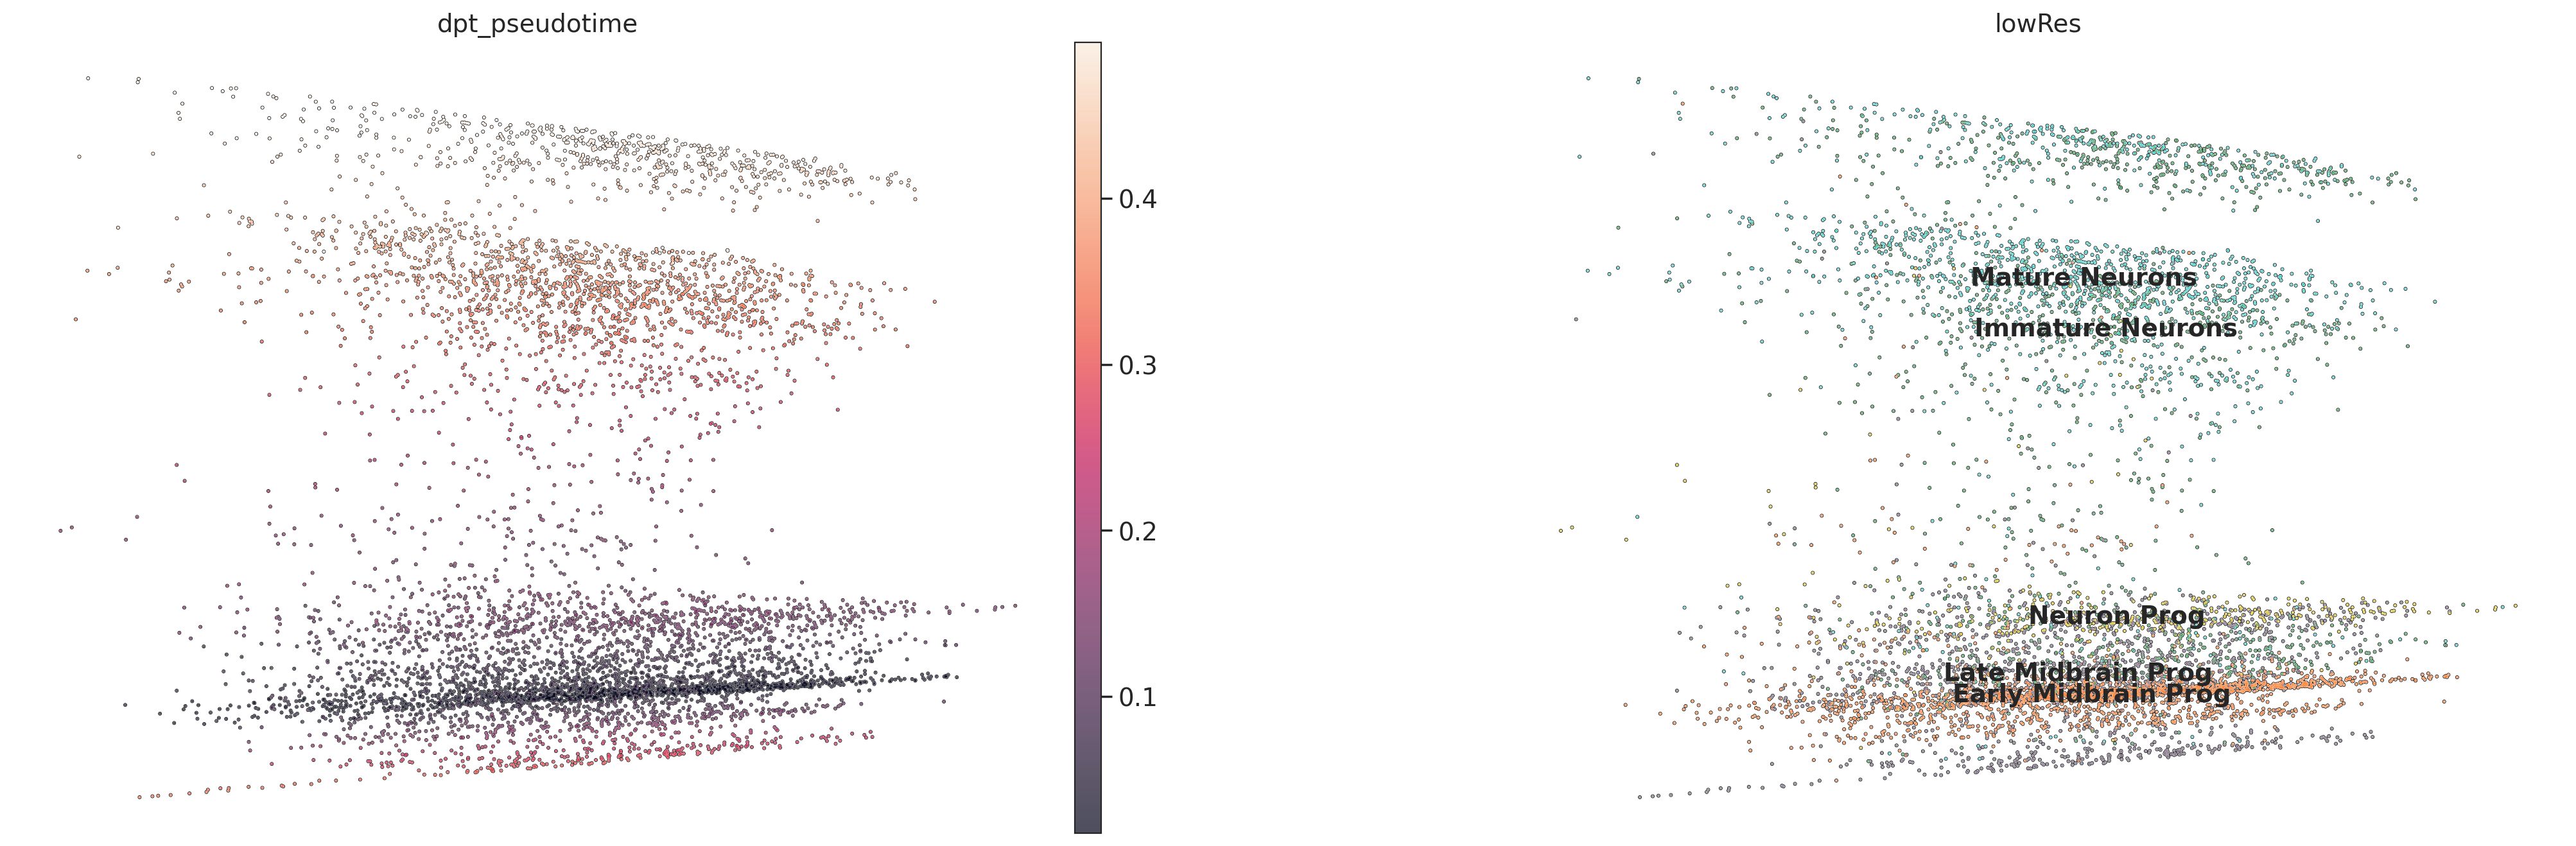

In [50]:
sc.pl.diffmap(adataTradeseq, color = ["dpt_pseudotime","lowRes"],
           size = 8, add_outline=True, outline_width=(0.2, 0.05), vmin='p2',vmax='p98', frameon=False, wspace=.3, legend_loc="on data")

/PUHTI_TYKKY_gU5QJ1k/miniforge/envs/env1/lib/python3.10/site-packages/scanpy/plotting/_utils.py:488: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


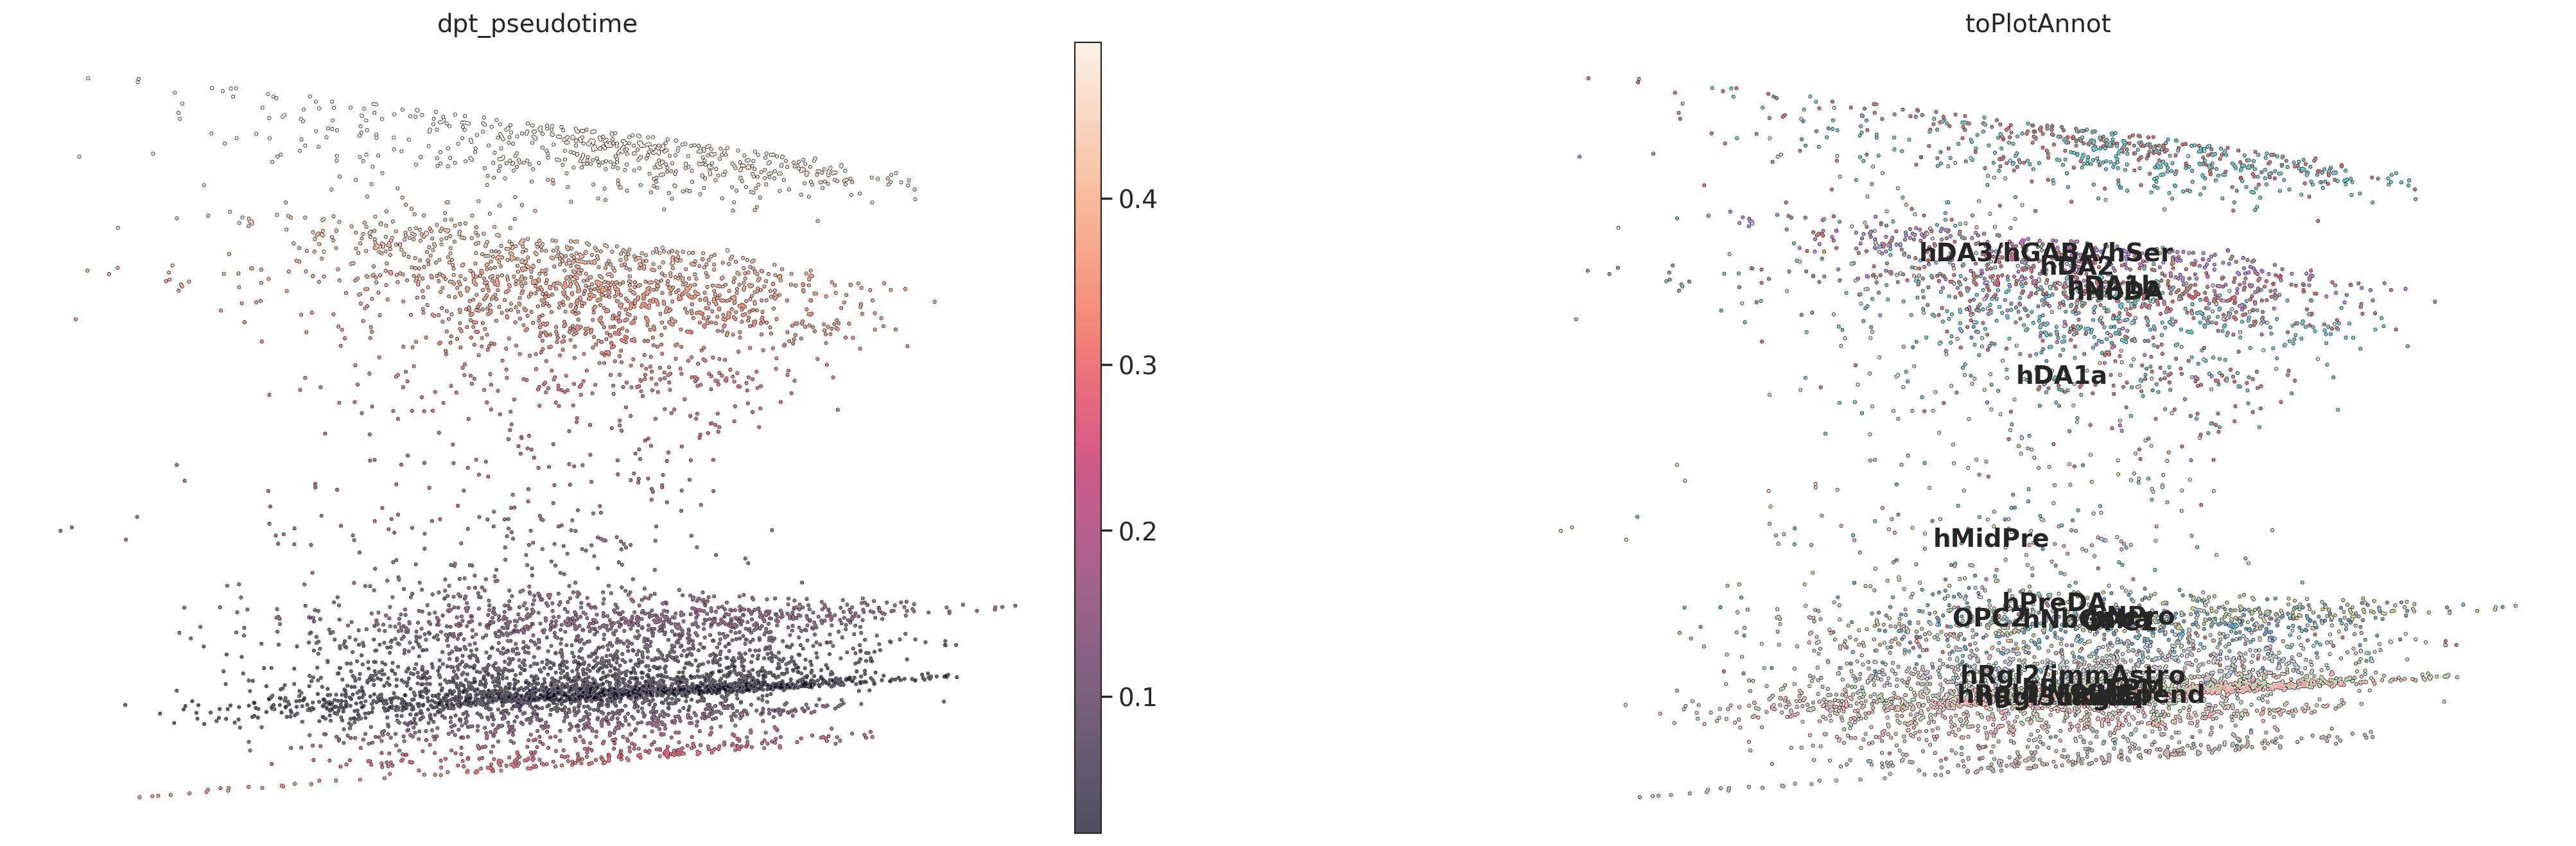

In [51]:
sc.pl.diffmap(adataTradeseq, color = ["dpt_pseudotime","toPlotAnnot"],
           size = 8, add_outline=True, outline_width=(0.2, 0.05), vmin='p2',vmax='p98', frameon=False, wspace=.3, legend_loc="on data")

In [52]:
adataTradeseq.obs[endpoint] = 1


In [53]:
cellWeights = adataTradeseq.obs[endpoint]
cellWeights = np.matrix(cellWeights.to_numpy()).T


pseudotime = adataTradeseq.obs["dpt_pseudotime"]
pseudotime = np.matrix(pseudotime.to_numpy()).T



# Transpose needed!
counts = adataTradeseq.X.T.todense()
counts = counts + abs(counts.min())

varnames = adataTradeseq.var_names.tolist()

In [54]:
# Save cellWeights
pd.DataFrame(cellWeights).to_csv(outdir+"cellWeights_neurons.csv", index=False, header=False)

# Save pseudotime
pd.DataFrame(pseudotime).to_csv(outdir+"pseudotime_neurons.csv", index=False, header=False)

# Save counts
pd.DataFrame(counts, index=varnames).to_csv(outdir+"counts_neurons.csv", index=True, header=False)